![alt text](img/ann-challenge-1.png)

In [30]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt 
from IPython import display
display.set_matplotlib_formats('svg')

def buildAndTrainTheModel(x,y):
    ANNreg = nn.Sequential(
        nn.Linear(1,1), #input layer (# of Inputs, # of Outputs) where # of Inputs = x values amd # Of Outputs = 1 which is input to outputlayer
        nn.ReLU(), # activation fcn. Rectified Linear Unit
        nn.Linear(1,1)  #output layer
    )
    # learning rate
    learningRate =  0.05

    # loss function
    lossfcn = nn.MSELoss() # object class that will implement the MSELOss fcn for us. 
    # optimzer (the falvor of gradient descent to implement)
    optimizer = torch.optim.SGD(ANNreg.parameters(),lr=learningRate) #stochastic GD

    # train the model
    numepochs = 500
    losses = torch.zeros(numepochs)

    ## Train the model!
    for epochi in range(numepochs):

        # forward pass
        yHat = ANNreg(x)

        # compute loss. recall we using MSE (the squared diff ..)
        loss = lossfcn(yHat,y) #predicted and observed (reality)
        losses[epochi] = loss # for grapning so we need a trail of losses and where they occurred

        #backprop
        optimizer.zero_grad()
        loss.backward() # runs backprop based on the losses we experienced from the lossfcn() call
        optimizer.step()
    #end training loop
    
    ### Compute model predictions
    predictions = ANNreg(x)

    # output:
    return predictions,losses





C:\Users\mpere\AppData\Local\Temp\ipykernel_32444\621866290.py:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [31]:
def createTheData(m):
    N = 50
    x = torch.randn(N,1)
    y = m*x + torch.randn(N,1)/2
    return x,y


# Test it Once

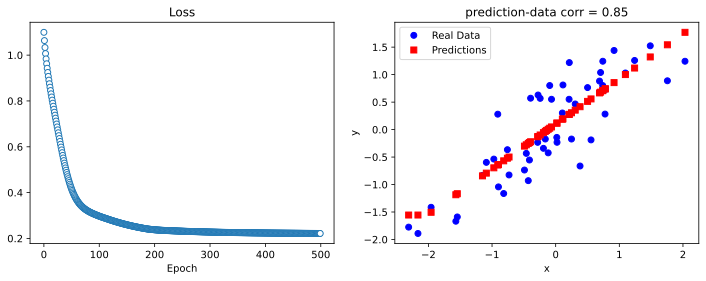

In [34]:

# create a dataset
x,y = createTheData(.8)

# run the model
yHat,losses = buildAndTrainTheModel(x,y)

fi,ax = plt.subplots(1,2,figsize=(12,4))

ax[0].plot(losses.detach(),'o',markerfacecolor='w',linewidth=.1)
ax[0].set_xlabel('Epoch')
ax[0].set_title('Loss')

ax[1].plot(x,y,'bo',label='Real Data')
ax[1].plot(x,yHat.detach(),'rs',label='Predictions')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].set_title(f'prediction-data corr = {np.corrcoef(y.T,yHat.detach().T)[0,1]:.2f}')
ax[1].legend()

plt.show()


## Now for the experiment!

In [35]:

# (takes 3 minutes wih 21 slopes and 50 experiements)

# the slopes to simulate

slopes = np.linspace(-2,2,21)

numExps = 50

# initialize output matrix
results = np.zeros((len(slopes),numExps,2))

for slopei in range(len(slopes)):

    for N in range(numExps):
        # create a datset and run the model
        x,y = createTheData(slopes[slopei])
        yHat,losses = buildAndTrainTheModel(x,y)

        # store the final loss and performance
        results[slopei,N,0] = losses[-1]
        results[slopei,N,1] = np.corrcoef(y.T,yHat.detach().T)[0,1] # correlation coefficient

# correlation can be 0 if the model didn't do well. Set nan's -> 0
results[np.isnan(results)] = 0




c:\Users\mpere\anaconda3\envs\pyTorch\Lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\mpere\anaconda3\envs\pyTorch\Lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


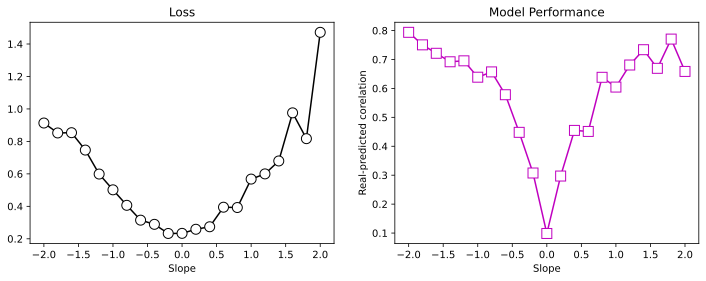

In [37]:
fig,ax = plt.subplots(1,2,figsize=(12,4))

ax[0].plot(slopes,np.mean(results[:,:,0],axis=1),'ko-',markerfacecolor='w',markersize=10)
ax[0].set_xlabel('Slope')
ax[0].set_title('Loss')

ax[1].plot(slopes,np.mean(results[:,:,1],axis=1),'ms-',markerfacecolor='w',markersize=10)
ax[1].set_xlabel('Slope')
ax[1].set_ylabel('Real-predicted corelation')
ax[1].set_title('Model Performance')

plt.show()


